©2026. For information, contact Deloitte Tohmatsu Group.

# 📝 演習概要

この演習では、MNISTを題材にニューラルネットワークの学習を改善する正則化手法を実装します。L2ノルム（Weight Decay）とドロップアウトをスクラッチで実装し、正則化あり/なしの比較を通じて過学習の抑制効果を確認します。各層クラスや最適化関数もNumPyで自作します。

## Pythonで手書き数字の画像データセット(MNIST)をダウンロードして前処理する

# **事前準備**

[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

また実行完了後に「ランタイムの再起動」をして下さい．

（以下のセルの実行は、最初にしていただければ、以降必要ありません．）


In [ ]:
# %%capture
# !pip uninstall matplotlib -y
# !pip install matplotlib==3.9.4

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.11.0.86

# !pip uninstall tensorflow -y
# !pip install tensorflow==2.19.0

# !pip uninstall torch -y
# !pip install torch==2.7.0

# !pip uninstall torchvision -y
# !pip install torchvision==0.22.0

## **データの準備**

In [ ]:
try:
    import urllib.request
except ImportError:
    raise ImportError('You should use Python 3.x')

import os.path
import gzip
import pickle
import os
import numpy as np

# MNISTデータの安定ダウンロード先（TensorFlow公式ミラー）
url_base = 'https://ossci-datasets.s3.amazonaws.com/mnist/'

# ダウンロードするファイル名をまとめた辞書
key_file = {
    'train_img': 'train-images-idx3-ubyte.gz',
    'train_label': 'train-labels-idx1-ubyte.gz',
    'test_img': 't10k-images-idx3-ubyte.gz',
    'test_label': 't10k-labels-idx1-ubyte.gz'
}

# データセットを保存するディレクトリ
dataset_dir = os.getcwd()
# pickle形式で保存するファイル名
save_file = dataset_dir + "/mnist.pkl"

train_num = 60000  # 訓練データ数
test_num = 10000   # テストデータ数
img_dim = (1, 28, 28)  # 画像の形状
img_size = 784     # 画像を一次元にした場合のサイズ（28*28）


def _download(file_name):
    """指定したファイルをダウンロードする"""
    file_path = dataset_dir + "/" + file_name

    if os.path.exists(file_path):
        return

    print("Downloading " + file_name + " ... ")
    urllib.request.urlretrieve(url_base + file_name, file_path)
    print("Done")


def download_mnist():
    """MNISTデータに必要なファイルをすべてダウンロードする"""
    for v in key_file.values():
        _download(v)


def _load_label(file_name):
    """ラベル（正解データ）を NumPy 配列として読み込む"""
    file_path = dataset_dir + "/" + file_name
    print("Converting " + file_name + " to NumPy Array ...")
    with gzip.open(file_path, 'rb') as f:
        labels = np.frombuffer(f.read(), np.uint8, offset=8)
    print("Done")
    return labels


def _load_img(file_name):
    """画像データを NumPy 配列として読み込む"""
    file_path = dataset_dir + "/" + file_name
    print("Converting " + file_name + " to NumPy Array ...")
    with gzip.open(file_path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    data = data.reshape(-1, img_size)
    print("Done")
    return data


def _convert_numpy():
    """訓練用・テスト用の画像とラベルをまとめて返す"""
    dataset = {}
    dataset['train_img'] = _load_img(key_file['train_img'])
    dataset['train_label'] = _load_label(key_file['train_label'])
    dataset['test_img'] = _load_img(key_file['test_img'])
    dataset['test_label'] = _load_label(key_file['test_label'])
    return dataset


def init_mnist():
    """MNISTデータをダウンロード→NumPy変換→pickle保存"""
    download_mnist()
    dataset = _convert_numpy()
    print("Creating pickle file ...")
    with open(save_file, 'wb') as f:
        pickle.dump(dataset, f, -1)
    print("Done!")


def _change_one_hot_label(X):
    """ラベル配列 X を one-hot ベクトルに変換する"""
    T = np.zeros((X.size, 10))
    for idx, row in enumerate(T):
        row[X[idx]] = 1
    return T


def load_mnist(normalize=True, flatten=True, one_hot_label=False):
    """pickleファイルからMNISTデータを読み込む"""
    if not os.path.exists(save_file):
        init_mnist()

    with open(save_file, 'rb') as f:
        dataset = pickle.load(f)

    if normalize:
        for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].astype(np.float32)
            dataset[key] /= 255.0

    if not flatten:
        for key in ('train_img', 'test_img'):
            dataset[key] = dataset[key].reshape(-1, 1, 28, 28)

    if one_hot_label:
        dataset['train_label'] = _change_one_hot_label(dataset['train_label'])
        dataset['test_label'] = _change_one_hot_label(dataset['test_label'])

    return (dataset['train_img'], dataset['train_label']), (dataset['test_img'], dataset['test_label'])




# **必要な関数、クラスの実装**

## 数値微分関数

In [ ]:
def numerical_gradient(f, x):
    h = 1e-4  # 微小な値（差分をとるためのステップ）
    grad = np.zeros_like(x)  # xと同じ形状の勾配を格納する配列を用意

    # np.nditerを使ってxのすべての要素を走査する
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index  # 現在注目している要素のインデックスを取得
        tmp_val = x[idx]      # xの元の値を一時的に保存

        # f(x+h) の計算
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h) の計算
        x[idx] = tmp_val - h
        fxh2 = f(x)

        # 中心差分により勾配を計算
        grad[idx] = (fxh1 - fxh2) / (2 * h)

        # xの値を元に戻す
        x[idx] = tmp_val

        # 次の要素に移動
        it.iternext()

    return grad

## 活性関数などの基礎関数

In [ ]:
def identity_function(x):
    """
    恒等関数: 入力をそのまま出力として返す
    """
    return x

def step_function(x):
    """
    ステップ関数: x > 0 のとき 1、 それ以外は 0 を返す
    """
    return np.array(x > 0, dtype=np.int)

def sigmoid(x):
    """
    シグモイド関数: 1 / (1 + exp(-x))
    """
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    """
    シグモイド関数の勾配(導関数):
    sigmoid(x) * (1 - sigmoid(x))
    """
    return (1.0 - sigmoid(x)) * sigmoid(x)

def relu(x):
    """
    ReLU関数: max(0, x)
    """
    return np.maximum(0, x)

def relu_grad(x):
    """
    ReLU関数の勾配:
    x >= 0 の要素に対しては 1、それ以外は 0
    """
    grad = np.zeros_like(x)
    grad[x >= 0] = 1
    return grad

def softmax(x):
    """
    ソフトマックス関数:
    出力値の総和が1になるように正規化する。オーバーフロー対策として最大値を引く。
    """
    x = x - np.max(x, axis=-1, keepdims=True)  # オーバーフロー防止
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

def sum_squared_error(y, t):
    """
    二乗和誤差 (SSE):
    0.5 * Σ (y - t)^2
    """
    return 0.5 * np.sum((y - t)**2)

def cross_entropy_error(y, t):
    """
    交差エントロピー誤差:
    - Σ [t_k * log(y_k)]
    教師データが one-hot の場合、正解ラベルのインデックスに変換してから計算。
    """
    if y.ndim == 1:
        # 入力が1次元の場合は、バッチ対応の形に整形
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 教師データ t が one-hot-vector の場合は、正解ラベルのインデックスに変換
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    # バッチ内の各正解ラベルの確率を取り出し、対数をとって平均
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

def softmax_loss(X, t):
    """
    ソフトマックス関数と交差エントロピー誤差を組み合わせた損失関数
    """
    y = softmax(X)
    return cross_entropy_error(y, t)


## 最適化関数

In [ ]:
class SGD:

    """確率的勾配降下法（Stochastic Gradient Descent）"""

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

## 層クラス

In [ ]:
class Relu:
    """
    ReLU(正の値はそのまま、0以下の値は0にする)を実装したレイヤ
    """
    def __init__(self):
        self.mask = None  # x <= 0 の真偽を保持するマスク

    def forward(self, x):
        """
        順伝播計算
        0以下の要素を0に置き換える。
        """
        self.mask = (x <= 0)     # x <= 0 の要素が True となるブール配列
        out = x.copy()
        out[self.mask] = 0      # Trueの位置を0にする

        return out

    def backward(self, dout):
        """
        逆伝播計算
        順伝播時に0以下だった要素は伝播しない(=0になる)。
        """
        dout[self.mask] = 0     # 0以下の要素に対応する位置は勾配を0に
        dx = dout

        return dx


class Sigmoid:
    """
    シグモイド関数を実装したレイヤ
    """
    def __init__(self):
        self.out = None  # 順伝播時の出力を保持

    def forward(self, x):
        """
        順伝播計算
        シグモイド関数を適用する。
        """
        out = sigmoid(x)
        self.out = out
        return out

    def backward(self, dout):
        """
        逆伝播計算
        (dout) * (1.0 - out) * out
        """
        dx = dout * (1.0 - self.out) * self.out

        return dx


class Affine:
    """
    全結合(アフィン)層を実装したレイヤ
    出力: xW + b
    """
    def __init__(self, W, b):
        """
        Parameters
        ----------
        W : 重み
        b : バイアス
        """
        self.W = W
        self.b = b

        self.x = None
        self.original_x_shape = None
        # パラメータ更新で使用する微分
        self.dW = None
        self.db = None

    def forward(self, x):
        """
        順伝播計算
        入力 x を2次元配列に変換して xW + b を計算する。
        """
        # テンソル対応：入力が(バッチサイズ, チャネル, 高さ, 幅)の形をしている場合、
        # dot演算のために2次元にフラット化して扱う
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        """
        逆伝播計算
        dW, db を求め、次の層へ渡す勾配 dx を計算する。
        """
        dx = np.dot(dout, self.W.T)        # 上流からの勾配をW^Tで伝播
        self.dW = np.dot(self.x.T, dout)   # x^T と dout から dW を計算
        self.db = np.sum(dout, axis=0)     # バイアスの勾配は要素方向に総和

        # 入力データの形状を元に戻す（CNN等での画像を取り扱うため）
        dx = dx.reshape(*self.original_x_shape)
        return dx


class SoftmaxWithLoss:
    """
    ソフトマックス関数 + 交差エントロピー誤差をまとめたレイヤ
    """
    def __init__(self):
        self.loss = None  # 損失(交差エントロピー誤差)
        self.y = None     # ソフトマックスの出力
        self.t = None     # 教師データ(ラベル)

    def forward(self, x, t):
        """
        順伝播計算
        x に softmax を適用し、t と比較して cross_entropy_error を求める。
        """
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        """
        逆伝播計算
        softmaxの出力 - 正解ラベル をバッチサイズで割り勾配を求める。
        dout は通常 1 が与えられる。
        """
        batch_size = self.t.shape[0]
        # 教師データ t が one-hot の場合
        if self.t.size == self.y.size:
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size

        return dx


## **ニューラルネットワークの設定**

In [ ]:
import numpy as np
from collections import OrderedDict

class MultiLayerNet:
    """全結合による多層ニューラルネットワーク
    Parameters
    ----------
    input_size : 入力サイズ（MNISTの場合は784）
    hidden_size_list : 隠れ層のニューロンの数のリスト（e.g. [100, 100, 100]）
    output_size : 出力サイズ（MNISTの場合は10）
    activation : 'relu' or 'sigmoid'
    weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
        'relu'または'he'を指定した場合は「Heの初期値」を設定
        'sigmoid'または'xavier'を指定した場合は「Xavierの初期値」を設定
    weight_decay_lambda : Weight Decay（L2ノルム）の強さ
    """
    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0):
        # --- ネットワーク構成の基本属性 ---
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.weight_decay_lambda = weight_decay_lambda  # L2正則化の係数（0なら無効）
        self.params = {}  # 各層のW,bを格納する辞書

        # --- 重みの初期化（He/Xavierなど） ---
        self.__init_weight(weight_init_std)

        # --- 順伝播で使うレイヤの組み立て ---
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}  # 活性化の種類をクラスに対応づけ
        self.layers = OrderedDict()  # 順序つき辞書（forward順序を維持）
        for idx in range(1, self.hidden_layer_num+1):
            # Affine -> Activation を hidden層の数だけ積む
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

        # 出力層（活性化なし：Softmaxは損失レイヤでまとめて実施）
        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
            self.params['b' + str(idx)])

        # 損失（Softmax + CE）を最後にまとめるレイヤ
        self.last_layer = SoftmaxWithLoss()

    def __init_weight(self, weight_init_std):
        """重みの初期値設定
        Parameters
        ----------
        weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
            'relu'または'he'を指定した場合は「Heの初期値」を設定
            'sigmoid'または'xavier'を指定した場合は「Xavierの初期値」を設定
        """
        # 各層の入出力サイズリストを作成（[入力, hidden..., 出力]）
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            # 初期化スケールの決定（文字列で指定された場合にHe/Xavierへ置換）
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx - 1])  # ReLUに適したHe初期化
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # Sigmoidに適したXavier

            # W: (前層ユニット数, 当該層ユニット数), b: (当該層ユニット数,)
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])

    def predict(self, x):
        # --- 順伝播（出力のロジットを返す）---
        for layer in self.layers.values():
            x = layer.forward(x)
        return x

    def loss(self, x, t):
        """損失関数を求める（交差エントロピー + L2正則化）"""
        # 予測スコア（ロジット）
        y = self.predict(x)

        # L2正則化項の加算（各Wに対して 0.5 * λ * ||W||^2）
        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2)

        # SoftmaxWithLoss がCEを返すので足し合わせて返す
        return self.last_layer.forward(y, t) + weight_decay

    def accuracy(self, x, t):
        # --- 精度評価（argmaxでクラス予測、one-hotも整数ラベルに揃える） ---
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def numerical_gradient(self, x, t):
        """勾配を求める"""
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        # 各層のW,bについて中心差分で勾配を推定
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = numerical_gradient(loss_W, self.params['W' + str(idx)])
            grads['b' + str(idx)] = numerical_gradient(loss_W, self.params['b' + str(idx)])
        return grads

    def gradient(self, x, t):
        """勾配を求める（誤差逆伝搬法：高速、本番用）"""
        # forward（loss内部でSoftmax+CEが実行され、last_layerに中間が保持される）
        self.loss(x, t)

        # backward（出力側から伝搬開始）
        dout = 1
        dout = self.last_layer.backward(dout)

        # 逆順に各レイヤへ逆伝播
        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 各Affineから勾配(dW, db)を回収し、L2の微分(λW)をdWへ加算
        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.layers['Affine' + str(idx)].W
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db
        return grads

In [ ]:
import numpy as np
from collections import OrderedDict

class MultiLayerNetExtend:
    """拡張版の全結合による多層ニューラルネットワーク

    Weiht Decay、Dropout、Batch Normalizationの機能を持つ
    Parameters
    ----------
    input_size : 入力サイズ（MNISTの場合は784）
    hidden_size_list : 隠れ層のニューロンの数のリスト（e.g. [100, 100, 100]）
    output_size : 出力サイズ（MNISTの場合は10）
    activation : 'relu' or 'sigmoid'
    weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
        'relu'または'he'を指定した場合は「Heの初期値」を設定
        'sigmoid'または'xavier'を指定した場合は「Xavierの初期値」を設定
    weight_decay_lambda : Weight Decay（L2ノルム）の強さ
    use_dropout: Dropoutを使用するかどうか
    dropout_ration : Dropoutの割り合い
    use_batchNorm: Batch Normalizationを使用するかどうか
    """
    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0,
                 use_dropout = False, dropout_ration = 0.5, use_batchnorm=False):
        # --- 構成・ハイパーパラメータの保持 ---
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.use_dropout = use_dropout
        self.weight_decay_lambda = weight_decay_lambda
        self.use_batchnorm = use_batchnorm
        self.params = {}

        # 重みの初期化
        self.__init_weight(weight_init_std)

        # レイヤの生成
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            if self.use_batchnorm:
                # BNのスケール・バイアス（γ, β）もparamsで管理
                self.params['gamma' + str(idx)] = np.ones(hidden_size_list[idx-1])
                self.params['beta' + str(idx)] = np.zeros(hidden_size_list[idx-1])
                self.layers['BatchNorm' + str(idx)] = BatchNormalization(self.params['gamma' + str(idx)], self.params['beta' + str(idx)])

            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

            if self.use_dropout:
                # 学習時のみユニット無効化、推論時は期待値スケーリング
                self.layers['Dropout' + str(idx)] = Dropout(dropout_ration)

        # 出力層（活性化なし）
        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)], self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()

    def __init_weight(self, weight_init_std):
        """重みの初期値設定
        Parameters
        ----------
        weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
            'relu'または'he'を指定した場合は「Heの初期値」を設定
            'sigmoid'または'xavier'を指定した場合は「Xavierの初期値」を設定
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx - 1])  # ReLUを使う場合に推奨される初期値
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # sigmoidを使う場合に推奨される初期値
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])

    def predict(self, x, train_flg=False):
        for key, layer in self.layers.items():
            if "Dropout" in key or "BatchNorm" in key:
                x = layer.forward(x, train_flg)  # train_flgを渡す
            else:
                x = layer.forward(x)

        return x

    def loss(self, x, t, train_flg=False):
        """損失関数を求める
        引数のxは入力データ、tは教師ラベル
        """
        y = self.predict(x, train_flg)

        # L2正則化
        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)

        return self.last_layer.forward(y, t) + weight_decay

    def accuracy(self, x, t):
        # --- 推論モードで精度評価 ---
        y = self.predict(x, train_flg=False)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def numerical_gradient(self, x, t):
        """勾配を求める（数値微分）
        Parameters
        ----------
        x : 入力データ
        t : 教師ラベル
        Returns
        -------
        各層の勾配を持ったディクショナリ変数
            grads['W1']、grads['W2']、...は各層の重み
            grads['b1']、grads['b2']、...は各層のバイアス
        """
        loss_W = lambda W: self.loss(x, t, train_flg=True)

        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = numerical_gradient(loss_W, self.params['W' + str(idx)])
            grads['b' + str(idx)] = numerical_gradient(loss_W, self.params['b' + str(idx)])

            if self.use_batchnorm and idx != self.hidden_layer_num+1:
                # BNパラメータ(gamma, beta)の数値微分
                grads['gamma' + str(idx)] = numerical_gradient(loss_W, self.params['gamma' + str(idx)])
                grads['beta' + str(idx)] = numerical_gradient(loss_W, self.params['beta' + str(idx)])

        return grads

    def gradient(self, x, t):
        # forward
        self.loss(x, t, train_flg=True)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        # 逆順で全レイヤへ
        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # --- 勾配の回収（L2のλWも加算） ---
        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.params['W' + str(idx)]
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

            if self.use_batchnorm and idx != self.hidden_layer_num+1:
                grads['gamma' + str(idx)] = self.layers['BatchNorm' + str(idx)].dgamma
                grads['beta' + str(idx)] = self.layers['BatchNorm' + str(idx)].dbeta

        return grads

## 学習クラス

In [ ]:
class Trainer:
    """ニューラルネットの訓練を行うクラス
    """
    def __init__(self, network, x_train, t_train, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='SGD', optimizer_param={'lr':0.01},
                 evaluate_sample_num_per_epoch=None, verbose=True):
        self.network = network
        self.verbose = verbose
        self.x_train = x_train
        self.t_train = t_train
        self.x_test = x_test
        self.t_test = t_test
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.evaluate_sample_num_per_epoch = evaluate_sample_num_per_epoch  # Noneで全件評価

        # optimizer
        optimizer_class_dict = {'sgd':SGD,}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)

        # 反復回数の計算
        self.train_size = x_train.shape[0]
        self.iter_per_epoch = max(self.train_size / mini_batch_size, 1)
        self.max_iter = int(epochs * self.iter_per_epoch)
        self.current_iter = 0
        self.current_epoch = 0

        # ログ
        self.train_loss_list = []
        self.train_acc_list = []
        self.test_acc_list = []

    def train_step(self):
        # --- ミニバッチをランダムサンプリング ---
        batch_mask = np.random.choice(self.train_size, self.batch_size)
        x_batch = self.x_train[batch_mask]
        t_batch = self.t_train[batch_mask]

        # --- 勾配計算 & パラメータ更新 ---
        grads = self.network.gradient(x_batch, t_batch)
        self.optimizer.update(self.network.params, grads)

        # --- ロス計測（学習ログ） ---
        loss = self.network.loss(x_batch, t_batch)
        self.train_loss_list.append(loss)
        if self.verbose: print("train loss:" + str(loss))

        # --- エポック境界での精度計測・ログ ---
        if self.current_iter % self.iter_per_epoch == 0:
            self.current_epoch += 1

            # 評価件数の制限
            x_train_sample, t_train_sample = self.x_train, self.t_train
            x_test_sample, t_test_sample = self.x_test, self.t_test
            if not self.evaluate_sample_num_per_epoch is None:
                t = self.evaluate_sample_num_per_epoch
                x_train_sample, t_train_sample = self.x_train[:t], self.t_train[:t]
                x_test_sample, t_test_sample = self.x_test[:t], self.t_test[:t]

            # 学習/テスト精度を記録
            train_acc = self.network.accuracy(x_train_sample, t_train_sample)
            test_acc = self.network.accuracy(x_test_sample, t_test_sample)
            self.train_acc_list.append(train_acc)
            self.test_acc_list.append(test_acc)

            if self.verbose: print("=== epoch:" + str(self.current_epoch) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc) + " ===")
        self.current_iter += 1

    def train(self):
        # --- 既定の反復回数まで学習 ---
        for i in range(self.max_iter):
            self.train_step()

        # --- 最終テスト精度の表示 ---
        test_acc = self.network.accuracy(self.x_test, self.t_test)

        if self.verbose:
            print("=============== Final Test Accuracy ===============")
            print("test acc:" + str(test_acc))

# **L2Norm**

過学習の抑制のために、Weight decay(荷重減衰)を行う。

Weight decayとは、学習の過程で、大きな重みをもつことに対してペナルティを与えることで、過学習をおさえようする手法をさす。

損失関数の値を小さくすることを目的とするニューラルネットワークの学習において、重みの絶対値ノルム（L1ノルム）や二乗ノルム（L2ノルム）、最大ノルム（L∞ノルム）などを正則化項として損失関数に加算することで重みが大きくなることを防ぐことができる。
それぞれに特徴があるが、最も一般的なL2Normを今回は実装する。

なお、ノルム (norm)とは、平面あるいは空間における幾何学的ベクトルの "長さ" の概念の一般化であり、ベクトル空間に対して「距離」を与えるための数学の道具のことを指す。またLはLebesgue spaces：ルベーグ空間を意味している。

In [ ]:
# L2ノルムを実装した損失関数
# 1/2λW^2を損失関数に加算する。
# Wは重み、λは正則化の強さを表すハイパーパラメータとなる。
# λを大きくすればするほど、大きな重みをとることへペナルティを課すことを意味する。
# 先頭の1/2は微分した結果をλWにするための調整用の定数

def loss(self, x, t):
  y = self.predict(x)  # 通常の順伝播でロジット/スコアを取得

  # L2ノルムの実装
  # すべての重みの損失関数に、1/2λW^2を加算する。
  # そのため、重みの勾配を求める誤差逆伝播法による結果に対して、正則化項の微分λWを加算することになる。

  # L2ノルム（Weight Decay）の加算項を組み立てる
  weight_decay = 0
  for idx in range(1, self.hidden_layer_num + 2):
    W = self.params['W' + str(idx)]
    weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2)

  # Softmax + 交差エントロピーの損失に L2項を足して返す
  return self.last_layer.forward(y, t) + weight_decay

## L2ノルムを実装しなかった場合

Done
Done
Done
Done
Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!
epoch:0, train acc:0.08666666666666667, test acc:0.1
epoch:1, train acc:0.11, test acc:0.1109
epoch:2, train acc:0.13333333333333333, test acc:0.1271
epoch:3, train acc:0.15666666666666668, test acc:0.1398
epoch:4, train acc:0.19666666666666666, test acc:0.1552
epoch:5, train acc:0.21, test acc:0.1669
epoch:6, train acc:0.24666666666666667, test acc:0.1798
epoch:7, train acc:0.27, test acc:0.1944
epoch:8, train acc:0.31333333333333335, test acc:0.2186
epoch:9, train acc:0.36, test acc:0.2421
epoch:10, train acc:0.36666666666666664, test acc:0.2635
epoch:11, train acc:0.37, test acc:0.2717
epoch:12, train acc:0.39666666666666667, test acc:0.2968
epoch:13, train acc:0.4066666666666667, test acc:0

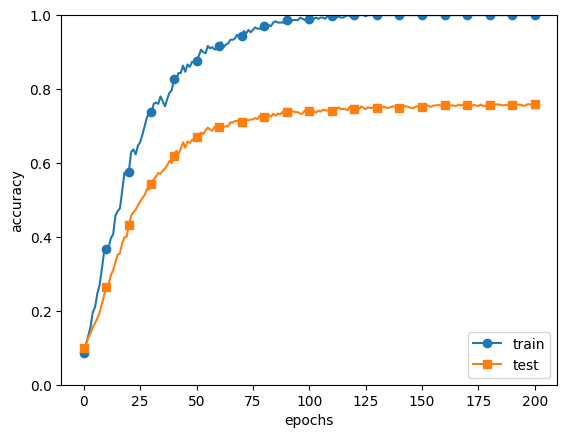

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- データロード（外部の load_mnist を想定） ---
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（荷重減衰）の設定 =======================
weight_decay_lambda = 0
#weight_decay_lambda = 0.1 # weight decayを使用する場合
# ====================================================

# ネットワーク構築
network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1エポックあたりのイテレーション回数
iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000):
    # --- ミニバッチのサンプリング ---
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # --- 勾配計算 & パラメータ更新 ---
    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    # --- エポック境界で精度評価・ログ ---
    if i % iter_per_epoch == 0:
        # エポックごとの train/test 精度
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break

# --- 学習曲線の描画（wd=0 のケース） ---
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

## L2ノルムを実装した場合

In [ ]:
# L2ノルムを実装した場合
import os
import numpy as np
import matplotlib.pyplot as plt

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（荷重減衰）の設定 =======================
#weight_decay_lambda = 0 # weight decayを使用しない場合
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    # --- ミニバッチ ---
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # --- 更新 ---
    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    # --- エポック評価 ---
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break

# --- 学習曲線の描画（wd=0.1 のケース） ---
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.11, test acc:0.0952
epoch:1, train acc:0.11, test acc:0.0975
epoch:2, train acc:0.11666666666666667, test acc:0.0981
epoch:3, train acc:0.11, test acc:0.0991
epoch:4, train acc:0.11333333333333333, test acc:0.1015
epoch:5, train acc:0.12, test acc:0.104
epoch:6, train acc:0.12666666666666668, test acc:0.1056
epoch:7, train acc:0.13, test acc:0.1096
epoch:8, train acc:0.13666666666666666, test acc:0.1182
epoch:9, train acc:0.15666666666666668, test acc:0.1227
epoch:10, train acc:0.18666666666666668, test acc:0.1348
epoch:11, train acc:0.2, test acc:0.14
epoch:12, train acc:0.23666666666666666, test acc:0.1637
epoch:13, train acc:0.2633333333333333, test acc:0.1814
epoch:14, train acc:0.2833333333333333, test acc:0.2037
epoch:15, train acc:0.30333333333333334, test acc:0.2164
epoch:16, train acc:0.31333333333333335, test acc:0.2303
epoch:17, train acc:0.32, test acc:0.2387
epoch:18, train acc:0.34, test acc:0.2608
epoch:19, train acc:0.3466666666666667, test acc:0.25

# ドロップアウト

In [ ]:
class Dropout:
    """
    http://arxiv.org/abs/1207.0580
    - 学習時: 各要素を独立に keep/drop（Bernoulli）し、落としたユニットは0にする
    - 推論時: 期待値が一致するように (1 - dropout_ratio) 倍でスケーリング
    """
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio  # dropする割合（例: 0.5 なら半分を無効化）
        self.mask = None  # 学習時に生成するブールマスク（True=keep, False=drop）

    def forward(self, x, train_flg=True):
        if train_flg:
            # U(0,1) > ratio を True とするブールマスク。shape は x と同一。
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            # ブロードキャストでそのまま要素積
            return x * self.mask
        else:
            # 推論ではユニットを落とさない代わりに期待値スケーリング
            return x * (1.0 - self.dropout_ratio)

    def backward(self, dout):
        # dropした位置の勾配は流さない（=0）。keepした位置だけ伝播。
        return dout * self.mask

## ドロップアウトがない場合

In [ ]:
x_train = x_train[:300]
t_train = t_train[:300]

# Dropuoutの有無、割り合いの設定 ========================
use_dropout = False  # Dropoutなしのときの場合はFalseに
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)

trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 学習曲線（Dropoutなし）
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

## ドロップアウトがある場合

In [ ]:
x_train = x_train[:300]
t_train = t_train[:300]

# Dropuoutの有無、割り合いの設定 ========================
use_dropout = True           # Dropoutなしのときの場合はFalseに
dropout_ratio = 0.2          # 20% を drop
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 学習曲線（Dropoutあり）
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

# バッチ正規化

In [ ]:
class BatchNormalization:
    """
    http://arxiv.org/abs/1502.03167
    - 学習時: バッチ平均/分散で正規化し、移動平均(running_mean/var)を更新
    - 推論時: 学習で蓄えた移動平均/分散で正規化（バッチに依存しない）
    - ここでは全結合（2次元）とConv（4次元）両対応のため reshape で往復
    """
    def __init__(self, gamma, beta, momentum=0.9, running_mean=None, running_var=None):
        self.gamma = gamma     # スケール（学習対象）
        self.beta = beta       # シフト（学習対象）
        self.momentum = momentum
        self.input_shape = None # Conv層の場合は4次元、全結合層の場合は2次元

        # テスト時に使用する平均と分散
        self.running_mean = running_mean
        self.running_var = running_var

        # backward時に使用する中間データ
        self.batch_size = None
        self.xc = None
        self.std = None
        self.dgamma = None
        self.dbeta = None

    def forward(self, x, train_flg=True):
        self.input_shape = x.shape
        # Conv対応: (N,C,H,W) -> (N, C*H*W) へ平坦化
        if x.ndim != 2:
            N, C, H, W = x.shape
            x = x.reshape(N, -1)

        out = self.__forward(x, train_flg)

        # 入力形状に戻す
        return out.reshape(*self.input_shape)

    def __forward(self, x, train_flg):
        # running_* が未初期化なら形状に合わせて0で用意
        if self.running_mean is None:
            N, D = x.shape
            self.running_mean = np.zeros(D)
            self.running_var = np.zeros(D)

        if train_flg:
            # バッチ統計で正規化
            mu = x.mean(axis=0)          # バッチ平均
            xc = x - mu                  # 中心化
            var = np.mean(xc**2, axis=0) # 分散
            std = np.sqrt(var + 10e-7)   # 標準偏差（ゼロ割防止のε付き）
            xn = xc / std                # 標準化

            # 中間値を保存（backwardで使用）
            self.batch_size = x.shape[0]
            self.xc = xc
            self.xn = xn
            self.std = std

            # 移動平均・移動分散を更新
            self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * mu
            self.running_var = self.momentum * self.running_var + (1-self.momentum) * var
        else:
            # 推論時は学習で貯めた統計を使う
            xc = x - self.running_mean
            xn = xc / ((np.sqrt(self.running_var + 10e-7)))

        # γ・βで線形変換（学習可能パラメータ）
        out = self.gamma * xn + self.beta
        return out

    def backward(self, dout):
        # Conv対応: (N,C,H,W) -> (N, C*H*W) に一時変換
        if dout.ndim != 2:
            N, C, H, W = dout.shape
            dout = dout.reshape(N, -1)

        dx = self.__backward(dout)

        # 元形状へ戻す
        dx = dx.reshape(*self.input_shape)
        return dx

    def __backward(self, dout):
        # β, γ の勾配は素直に和と内積で出る
        dbeta = dout.sum(axis=0)                  # ∂L/∂β = Σ_i dout_i
        dgamma = np.sum(self.xn * dout, axis=0)   # ∂L/∂γ = Σ_i xn_i * dout_i

        # 正規化部の逆伝播
        dxn = self.gamma * dout                   # ∂L/∂xn
        dxc = dxn / self.std                      # ∂L/∂xc の一部（stdは定数扱いで割り戻す）
        dstd = -np.sum((dxn * self.xc) / (self.std * self.std), axis=0)  # ∂L/∂std
        dvar = 0.5 * dstd / self.std              # ∂L/∂var（std = sqrt(var+ε) の鎖律）
        dxc += (2.0 / self.batch_size) * self.xc * dvar                  # var = mean(xc^2) の逆伝播
        dmu = np.sum(dxc, axis=0)                 # ∂L/∂mu
        dx = dxc - dmu / self.batch_size          # ∂L/∂x = ∂L/∂xc - 1/N * ∂L/∂mu

        # 勾配を保持
        self.dgamma = dgamma
        self.dbeta = dbeta

        return dx

##  バッチ正規化がない場合

In [ ]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 学習データを削減
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01  # SGDの学習率


def __train(weight_init_std):
    """
    指定した初期化スケールに対して、
    - BNなしネットワーク（bn_network）
    - BNありネットワーク（network：デフォでuse_batchnorm=True）
    の2つを同じバッチで並走学習し、train精度の推移を比較する。
    """
    # BNなしモデル
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                    weight_init_std=weight_init_std, use_batchnorm=False)
    # BNありモデル
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []     # BNありの学習精度ログ
    bn_train_acc_list = []  # BNなしの学習精度ログ

    # 1エポックあたりの反復回数
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        # --- 同一バッチを両モデルに与えて公平比較 ---
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 順に勾配計算→更新（BNなし→BNあり）
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        # エポック境界で学習精度（train）のみ比較
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)        # BNあり
            bn_train_acc = bn_network.accuracy(x_train, t_train)  # BNなし
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list


# グラフの描画
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)
plt.rcParams["figure.figsize"] = (25, 10)

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)

    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')

plt.show()

## バッチ正規がある場合

In [ ]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 学習データを削減
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    # BNあり
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    # デフォルト（BNなし）
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []     # BNなしの学習精度ログ
    bn_train_acc_list = []  # BNありの学習精度ログ

    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        # --- 同一バッチで並走学習 ---
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        if i % iter_per_epoch == 0:
            # ここでは bn_network が BNあり、network が BNなし
            train_acc = network.accuracy(x_train, t_train)        # BNなし
            bn_train_acc = bn_network.accuracy(x_train, t_train)  # BNあり
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list


# グラフの描画
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)
plt.rcParams["figure.figsize"] = (25, 10)

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)

    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)                     # BNあり
        plt.plot(x, train_acc_list, linestyle="--", label='Normal(without BatchNorm)', markevery=2)  # BNなし
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')

plt.show()